playground is to figure out how to have bar_iteration() update min_bright as necessary for dark vs. light mode

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
import new_utils

In [11]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [12]:
min_int = df_filtered['Grey Val'].min()
max_int = df_filtered['Grey Val'].max()
int_range = max_int - min_int

rgb = new_utils.rgb

y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
min_bright = 0.1

MIN_BRIGHT = 0.1

min_alpha = 0.1
min_alpha_scatter = 0.2
base_marker_size = 5
max_marker_size_factor = 95
gamma_factor = 0.8
bar_width = 1
smoothing_window = 5    # Increase this value to control the degree of smoothing
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be
x_min = 400
x_max = 750
reverse_x = True
show_grid = True
plot_type = None

x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

In [24]:
def get_mode():
    global mode
    inp = input(print("Choose Mode: Dark or Light")).lower()
    if inp == 'dark' or inp == 'd':
        mode = 'dark'
    elif inp == 'light' or inp == 'l':
        mode = 'light'

    print(mode)

In [20]:
def bar_iteration():
    bar_colors = []
    for index, row in df_filtered.iterrows():
        wavelength = row['nm']
        normalized_intensity = row['Normalized_int']
        if mode == 'dark':
            BRIGHT = 0.1
        if mode == 'light':
            BRIGHT = 0.7

        base_rgb = rgb(wavelength)
        final_intensity_scale = new_utils.final_scale(BRIGHT, normalized_intensity)
        

        color_rgb = new_utils.colored_rgb(base_rgb, final_intensity_scale)
        bar_colors.append(color_rgb)
    print(BRIGHT)
    print(mode)
    
    plt.bar(
        x=df_filtered['nm'],
        height=df_filtered['Grey Val'],
        width=bar_width,
        color=bar_colors,
        edgecolor='none' # No edge color for bars
    )

In [15]:
def axis_label(
    fig_size = (15, 6),
    show_grid = True,
    mode = None,
    reverse_x = None,
    x_min = 400,
    x_max = 750,
    x_title = "Wavelength (nm)",
    y_title = "Intensity",
    text = None,
):
    
    plt.figure(figsize=fig_size)
    ax = plt.gca()

    get_mode()

    if mode == 'dark' or mode == 'd':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        if show_grid is True:
            plt.grid(show_grid)
    
    reverse_x = input(print("Reverse x-axis? Yes or No")).lower()
    if reverse_x == 'yes' or reverse_x == 'y':
        reverse_x is True
        plt.xlim(x_max, x_min)
    else:
        reverse_x is False
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [16]:
def plot_graph():
    GRAPH_TYPE = input(print("Choose Graph Type: Line, Bar, Scatter, Gaussian")).lower()

    if GRAPH_TYPE == 'bar':
        bar_iteration()
        plt.title("Bar Chart", color = "white")

Choose Mode: Dark or Light
light
Reverse x-axis? Yes or No
Choose Graph Type: Line, Bar, Scatter, Gaussian
0.7
light


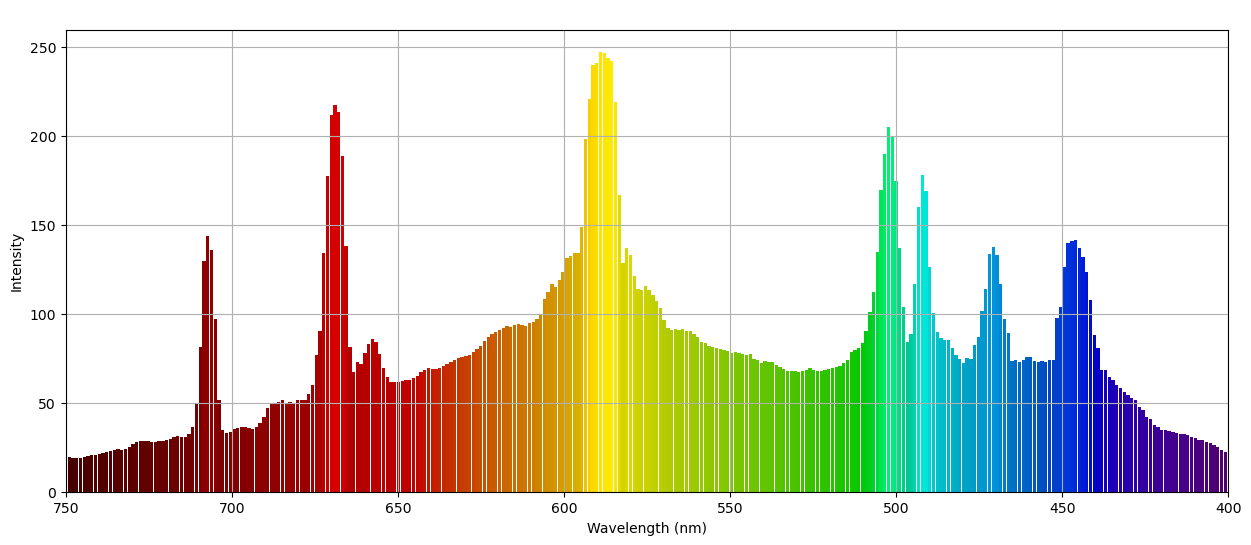

In [25]:
axis_label()
plot_graph()